🚀 STEP 1: Install Required Libraries

In [1]:
!pip install pandas numpy sqlite3 streamlit matplotlib seaborn

ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for sqlite3


📦 STEP 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import sqlite3
from datetime import datetime

📂 STEP 3: Load All Datasets

In [7]:
customers = pd.read_csv(r"d:\Users\pabha\Downloads\customers.csv")
accounts = pd.read_csv(r"d:\Users\pabha\Downloads\accounts.csv")
transactions = pd.read_csv(r"d:\Users\pabha\Downloads\transactions.csv")

loans = pd.read_csv(r"d:\Users\pabha\Downloads\loans.csv")
branches = pd.read_csv(r"d:\Users\pabha\Downloads\branches.csv")
support = pd.read_csv(r"d:\Users\pabha\Downloads\support_tickets.csv")

# JSON files
credit_cards = pd.read_json(r"d:\Users\pabha\Downloads\credit_cards.json")

🧹 STEP 4: Data Cleaning

In [8]:
# Remove duplicates
customers.drop_duplicates(inplace=True)
accounts.drop_duplicates(inplace=True)
transactions.drop_duplicates(inplace=True)

# Handle missing values
customers.fillna("Unknown", inplace=True)
accounts.fillna(0, inplace=True)
transactions.fillna("Unknown", inplace=True)

# Convert dates
customers['join_date'] = pd.to_datetime(customers['join_date'])
transactions['txn_time'] = pd.to_datetime(transactions['txn_time'])
accounts['last_updated'] = pd.to_datetime(accounts['last_updated'])

🗄️ STEP 5: Create SQLite Database

In [9]:
conn = sqlite3.connect("banksight.db")
cursor = conn.cursor()

🏗️ STEP 6: Create Tables

In [10]:
customers.to_sql("customers", conn, if_exists="replace", index=False)
accounts.to_sql("accounts", conn, if_exists="replace", index=False)
transactions.to_sql("transactions", conn, if_exists="replace", index=False)
loans.to_sql("loans", conn, if_exists="replace", index=False)
branches.to_sql("branches", conn, if_exists="replace", index=False)
support.to_sql("support_tickets", conn, if_exists="replace", index=False)
credit_cards.to_sql("credit_cards", conn, if_exists="replace", index=False)

557

STEP 7: SQL Queries (Core Analysis)

✅ Q1: Customers per City + Avg Balance

In [11]:
query = """
SELECT c.city, COUNT(c.customer_id) AS total_customers,
AVG(a.account_balance) AS avg_balance
FROM customers c
JOIN accounts a ON c.customer_id = a.customer_id
GROUP BY c.city
"""
pd.read_sql(query, conn)

,city,total_customers,avg_balance
0,Adamtown,1,45424.11
1,Alanton,1,392508.77
2,Albertchester,1,387844.67
3,Alexanderstad,1,383016.76
4,Alexfurt,1,403292.20
...,...,...,...
482,Wintershaven,1,455365.96
483,Woodfort,1,434936.56
484,Yanghaven,1,163152.58
485,Zacharychester,1,311439.87


✅ Q2: Account Type Highest Balance

In [12]:
query = """
SELECT account_type, SUM(account_balance) AS total_balance
FROM customers c
JOIN accounts a ON c.customer_id = a.customer_id
GROUP BY account_type
ORDER BY total_balance DESC
"""
pd.read_sql(query, conn)

,account_type,total_balance
0,Savings,61880483.18
1,Current,61617575.41


✅ Q3: Top 10 Customers

In [13]:
query = """
SELECT c.name, SUM(a.account_balance) AS total_balance
FROM customers c
JOIN accounts a ON c.customer_id = a.customer_id
GROUP BY c.customer_id
ORDER BY total_balance DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,name,total_balance
0,Amy Nguyen,498739.49
1,Carolyn Higgins,498317.41
2,Lisa Russell,497040.60
3,Amber Williams,494779.97
4,Audrey Peck,494699.91
5,Alvin Compton,484758.19
6,Sharon Bennett DVM,482746.37
7,Denise Campbell,481746.58
8,Jeffrey Smith,481568.14
9,Ann Crosby,479706.41


✅ Q4: 2023 High Balance Customers

In [14]:
query = """
SELECT *
FROM customers c
JOIN accounts a ON c.customer_id = a.customer_id
WHERE strftime('%Y', join_date) = '2023'
AND account_balance > 100000
"""
pd.read_sql(query, conn)

,customer_id,name,gender,age,city,account_type,join_date,customer_id,account_balance,last_updated
0,C0001,Richard Wilson,M,65,Kimberlyburgh,Savings,2023-08-27 00:00:00,C0001,293729.87,2025-05-24 09:46:29
1,C0002,Holly Parker,F,41,Port David,Current,2023-12-08 00:00:00,C0002,150735.15,2025-05-24 09:46:29
2,C0007,Jasmine Morris,M,69,Kristaborough,Savings,2023-10-09 00:00:00,C0007,291736.90,2025-05-24 09:46:29
3,C0017,Jesus Davenport,F,26,South Randyshire,Current,2023-06-07 00:00:00,C0017,345239.48,2025-05-24 09:46:29
4,C0021,William Jones,F,66,South Stephanie,Savings,2023-04-01 00:00:00,C0021,185053.68,2025-05-24 09:46:29
...,...,...,...,...,...,...,...,...,...,...
108,C0478,Ryan Jackson,M,37,East Deanstad,Current,2023-04-18 00:00:00,C0478,400751.68,2025-05-24 09:46:29
109,C0484,Rodney Cruz,F,66,Port Joseph,Savings,2023-03-09 00:00:00,C0484,150039.17,2025-05-24 09:46:29
110,C0489,Andrea Austin,M,63,West Ronald,Savings,2023-01-28 00:00:00,C0489,407686.39,2025-05-24 09:46:29
111,C0499,Alvin Compton,M,30,Millerstad,Current,2023-06-16 00:00:00,C0499,484758.19,2025-05-24 09:46:29


💳 TRANSACTION ANALYSIS

✅ Q5: Total Transaction Volume

In [15]:
query = """
SELECT txn_type, SUM(amount) AS total_volume
FROM transactions
GROUP BY txn_type
"""
pd.read_sql(query, conn)

,txn_type,total_volume
0,deposit,1.975748e+08
1,online fraud,2.382950e+07
2,purchase,7.383403e+07
3,transfer,5.059280e+07
4,withdrawal,1.513873e+08


✅ Q6: Failed Transactions

In [16]:
query = """
SELECT txn_type, COUNT(*) AS failed_count
FROM transactions
WHERE status = 'failed'
GROUP BY txn_type
"""
pd.read_sql(query, conn)

,txn_type,failed_count
0,deposit,433
1,online fraud,489
2,purchase,167
3,transfer,94
4,withdrawal,314


✅ Q8: High Value Transactions

In [17]:
query = """
SELECT customer_id, COUNT(*) AS high_txn_count
FROM transactions
WHERE amount > 20000
GROUP BY customer_id
HAVING COUNT(*) >= 5
"""
pd.read_sql(query, conn)

,customer_id,high_txn_count
0,C0001,16
1,C0002,9
2,C0003,15
3,C0004,11
4,C0005,11
...,...,...
495,C0496,25
496,C0497,17
497,C0498,13
498,C0499,17


🏦 LOAN ANALYSIS


✅ Q9: Avg Loan by Type

In [18]:
query = """
SELECT Loan_Type, AVG(Loan_Amount) AS avg_amount,
AVG(Interest_Rate) AS avg_interest
FROM loans
GROUP BY Loan_Type
"""
pd.read_sql(query, conn)

,Loan_Type,avg_amount,avg_interest
0,Auto,2.399261e+06,10.532523
1,Business,2.793969e+06,10.625437
2,Education,2.393948e+06,10.114393
3,Home,2.344577e+06,10.872479
4,Personal,2.461544e+06,10.463391


🚨 STEP 8: FRAUD DETECTION (IMPORTANT)

Z-Score Method

In [19]:
transactions['z_score'] = (
    (transactions['amount'] - transactions['amount'].mean()) /
    transactions['amount'].std()
)

fraud = transactions[transactions['z_score'].abs() > 3]
fraud.head()

,txn_id,customer_id,txn_type,amount,txn_time,status,z_score


Rule-Based Fraud

In [20]:
fraud_rules = transactions[
    (transactions['amount'] > 50000) |
    (transactions['txn_type'] == 'online fraud') |
    (transactions['status'] == 'failed')
]

fraud_rules.head()

,txn_id,customer_id,txn_type,amount,txn_time,status,z_score
2,T00003,C0084,withdrawal,82150.70,2024-07-31 18:28:06,success,1.116477
4,T00005,C0485,withdrawal,74536.08,2025-04-15 10:52:59,success,0.854317
5,T00006,C0093,transfer,85463.28,2024-12-05 02:21:45,success,1.230524
6,T00007,C0443,withdrawal,70966.85,2024-09-13 14:19:19,success,0.731434
7,T00008,C0080,withdrawal,80748.98,2025-02-19 14:58:58,success,1.068218


📊 STEP 9: Basic Visualization

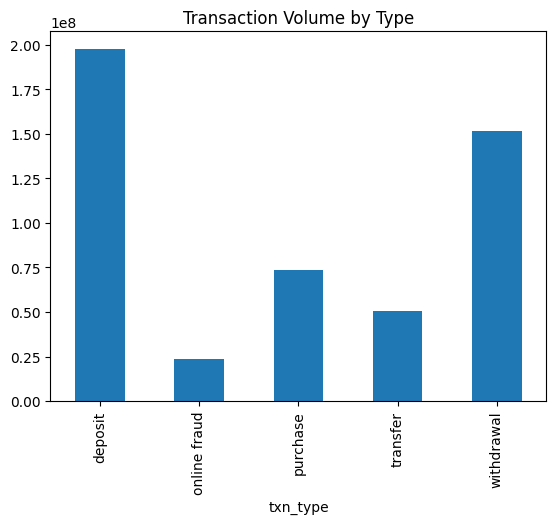

In [21]:
import matplotlib.pyplot as plt

transactions.groupby('txn_type')['amount'].sum().plot(kind='bar')
plt.title("Transaction Volume by Type")
plt.show()

💰 STEP 10: CREDIT / DEBIT SIMULATION

In [22]:
def deposit(customer_id, amount):
    query = f"""
    UPDATE accounts
    SET account_balance = account_balance + {amount}
    WHERE customer_id = '{customer_id}'
    """
    conn.execute(query)
    conn.commit()

def withdraw(customer_id, amount):
    balance = pd.read_sql(f"""
    SELECT account_balance FROM accounts
    WHERE customer_id = '{customer_id}'
    """, conn)

    if balance['account_balance'][0] - amount >= 1000:
        conn.execute(f"""
        UPDATE accounts
        SET account_balance = account_balance - {amount}
        WHERE customer_id = '{customer_id}'
        """)
        conn.commit()
    else:
        print("Minimum balance rule violated!")